🚀 啟動 V5 配對交易引擎 (富邦金 vs 國泰金)...


[*********************100%***********************]  2 of 2 completed


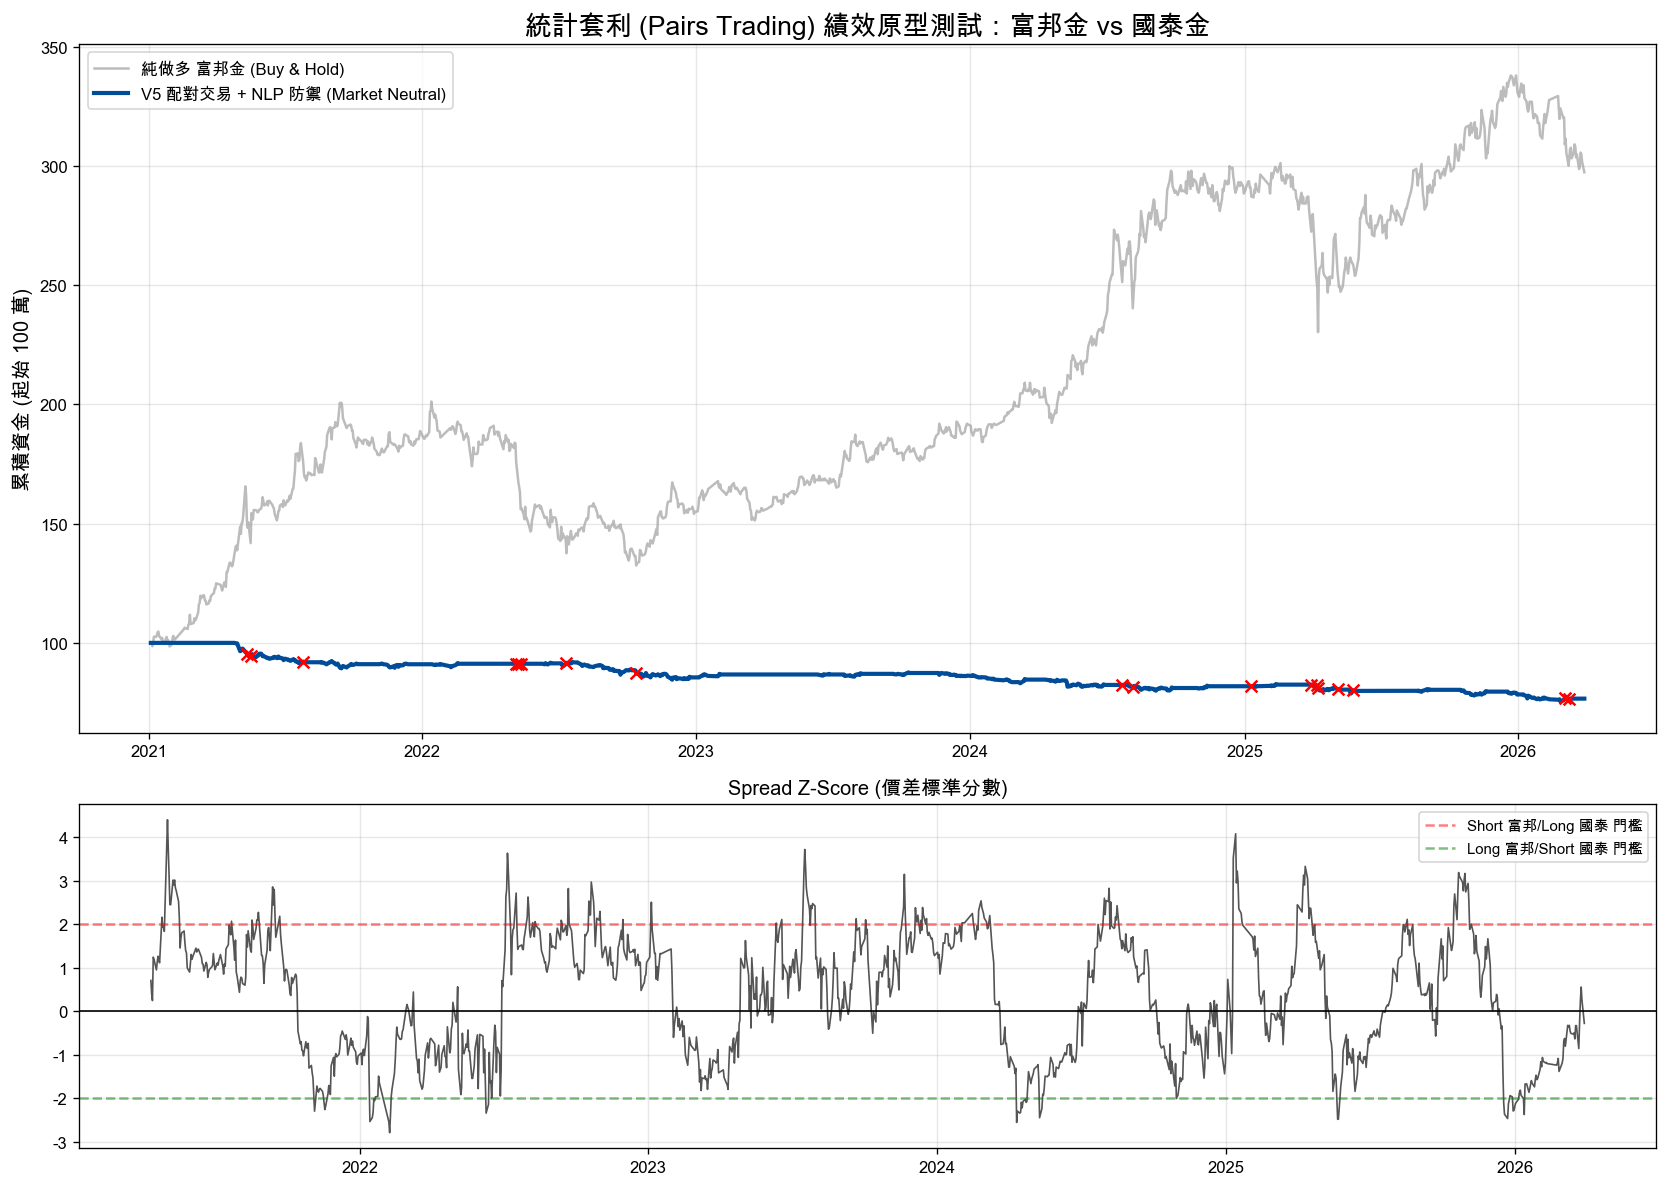

🏆 【V5 配對交易原型機：初步戰報】
純做多富邦金 (承擔大盤 100% 風險): 297.3 萬
V5 配對交易 (Market Neutral 市場中立): 76.6 萬


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang HK', 'Heiti TC', 'Microsoft JhengHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False 

print("🚀 啟動 V5 配對交易引擎 (富邦金 vs 國泰金)...")

# ==========================================
# 1. 獲取資料 (Data Fetching)
# ==========================================
tickers = ["2881.TW", "2882.TW"] # 富邦金, 國泰金
df = yf.download(tickers, start="2021-01-01", end="2026-03-31")['Close']
df = df.dropna()

fubon = df['2881.TW']
cathay = df['2882.TW']

# 每日報酬率
ret_fubon = fubon.pct_change().fillna(0)
ret_cathay = cathay.pct_change().fillna(0)

# ==========================================
# 2. 計算 Z-score (統計套利核心)
# ==========================================
# 計算兩者比值
ratio = fubon / cathay

# 使用 60 天 (季線) 作為滾動視窗來計算平均與標準差
window = 60
rolling_mean = ratio.rolling(window=window).mean()
rolling_std = ratio.rolling(window=window).std()

# 計算 Z-score
z_score = (ratio - rolling_mean) / rolling_std
df['Z_Score'] = z_score

# ==========================================
# 3. 模擬 NLP 恐慌濾網 (防禦 LTCM 黑天鵝)
# ==========================================
# 假設 PTT 鄉民在單日暴跌 > 4% 時會陷入極度恐慌 (NLP Panic Alert)
nlp_panic_alert = (ret_fubon < -0.04) | (ret_cathay < -0.04)

# ==========================================
# 4. 生成交易訊號 (Trading Signals)
# ==========================================
# 倉位狀態：1 (做多富邦/放空國泰), -1 (放空富邦/做多國泰), 0 (空手)
positions = np.zeros(len(df))

entry_threshold = 2.0  # 進場門檻 (Z-score > 2 或 < -2)
exit_threshold = 0.5   # 出場門檻 (回歸到 0.5 以內)

current_pos = 0
for i in range(window, len(df)):
    z = z_score.iloc[i]
    panic = nlp_panic_alert.iloc[i]
    
    # 🚨 NLP 黑天鵝防禦機制：情緒恐慌時，強制清倉不凹單！
    if panic:
        current_pos = 0
    else:
        # 尋找進場點
        if current_pos == 0:
            if z > entry_threshold:
                current_pos = -1 # 富邦太貴，Short 富邦 / Long 國泰
            elif z < -entry_threshold:
                current_pos = 1  # 富邦太便宜，Long 富邦 / Short 國泰
        # 尋找收斂出場點
        elif current_pos == -1 and z < exit_threshold:
            current_pos = 0
        elif current_pos == 1 and z > -exit_threshold:
            current_pos = 0
            
    positions[i] = current_pos

# ==========================================
# 5. 計算 Market Neutral 策略報酬
# ==========================================
# 因為是 Pairs Trading，做多一檔同時放空另一檔，資金各半 (0.5)
# 策略報酬 = 0.5 * (做多的報酬) - 0.5 * (放空的報酬)
# 注意：真實交易需考慮放空成本與保證金，此處為簡化版原型

positions_shifted = np.roll(positions, 1) # 昨天決定倉位，今天享受報酬
positions_shifted[0] = 0

strategy_returns = np.zeros(len(df))
for i in range(len(df)):
    if positions_shifted[i] == 1:
        strategy_returns[i] = 0.5 * ret_fubon.iloc[i] - 0.5 * ret_cathay.iloc[i]
    elif positions_shifted[i] == -1:
        strategy_returns[i] = 0.5 * ret_cathay.iloc[i] - 0.5 * ret_fubon.iloc[i]

# 加入簡單的摩擦成本 (每次倉位變動扣除 0.3% 雙邊綜合成本)
trades = np.abs(positions_shifted - np.roll(positions_shifted, 1))
friction_costs = trades * 0.003
strategy_returns = strategy_returns - friction_costs

# 累積報酬曲線
cum_strategy = np.cumprod(1 + strategy_returns)

# 大盤對照組 (單純 Buy & Hold 富邦金)
cum_fubon = np.cumprod(1 + ret_fubon)

# ==========================================
# 6. 畫圖分析
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]}, dpi=120)

# 上圖：資金曲線對決
ax1.plot(df.index, cum_fubon * 100, label='純做多 富邦金 (Buy & Hold)', color='#A0A0A0', alpha=0.7)
ax1.plot(df.index, cum_strategy * 100, label='V5 配對交易 + NLP 防禦 (Market Neutral)', color='#004C99', linewidth=2.5)
ax1.set_title('統計套利 (Pairs Trading) 績效原型測試：富邦金 vs 國泰金', fontsize=16, fontweight='bold')
ax1.set_ylabel('累積資金 (起始 100 萬)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 標示 NLP 恐慌觸發點 (紅色 X)
panic_dates = df.index[nlp_panic_alert]
ax1.scatter(panic_dates, cum_strategy[nlp_panic_alert] * 100, color='red', marker='x', s=50, label='🚨 NLP 恐慌清倉觸發', zorder=5)

# 下圖：Z-score 與進出場門檻
ax2.plot(df.index, z_score, color='#555555', linewidth=1)
ax2.axhline(entry_threshold, color='red', linestyle='--', alpha=0.5, label='Short 富邦/Long 國泰 門檻')
ax2.axhline(-entry_threshold, color='green', linestyle='--', alpha=0.5, label='Long 富邦/Short 國泰 門檻')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Spread Z-Score (價差標準分數)', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_bh = cum_fubon.iloc[-1] * 100
final_pairs = cum_strategy[-1] * 100
print(f"=========================================")
print(f"🏆 【V5 配對交易原型機：初步戰報】")
print(f"純做多富邦金 (承擔大盤 100% 風險): {final_bh:.1f} 萬")
print(f"V5 配對交易 (Market Neutral 市場中立): {final_pairs:.1f} 萬")
print(f"=========================================")